In [1]:
import yfinance as yf

In [2]:
btc = yf.download('BTC-USD', period='10y', interval='1d', auto_adjust=False, progress=False)


In [3]:
if type(btc.columns).__name__ == 'MultiIndex':
    btc.columns = btc.columns.get_level_values(0)

if btc.empty:
    raise ValueError('No data downloaded for BTC-USD. Check internet connection and try again.')

btc.to_csv('btc.csv')


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [5]:
btc.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-03-01,435.122986,435.122986,439.653015,432.319000,437.916992,74895800
2016-03-02,423.989014,423.989014,435.916992,423.989014,435.131012,74955296
2016-03-03,421.651001,421.651001,425.372986,419.411011,423.911987,100484000
2016-03-04,410.938995,410.938995,425.178009,410.938995,421.835999,90856096
2016-03-05,400.570007,400.570007,411.256989,394.035004,410.781006,135384992


In [6]:
btc.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-02-25,67960.125000,67960.125000,69953.531250,63942.484375,64077.769531,53629234355
2026-02-26,67453.773438,67453.773438,68843.351562,66523.734375,67954.867188,42988597523
2026-02-27,65881.796875,65881.796875,68220.406250,64946.035156,67456.515625,40283655942
2026-02-28,66995.859375,66995.859375,67714.523438,63062.218750,65878.929688,42041497112
2026-03-01,66912.515625,66912.515625,68088.335938,66194.140625,66989.890625,40205033472


In [7]:
btc.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3653 entries, 2016-03-01 to 2026-03-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3653 non-null   float64
 1   Close      3653 non-null   float64
 2   High       3653 non-null   float64
 3   Low        3653 non-null   float64
 4   Open       3653 non-null   float64
 5   Volume     3653 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 199.8 KB


In [8]:
btc.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03
mean,31579.089098,31579.089098,32191.594187,30887.408240,31562.034103,2.515238e+10
std,32475.335988,32475.335988,33012.201587,31887.779758,32474.770894,2.295180e+10
min,400.570007,400.570007,410.984009,394.035004,400.524994,2.851400e+07
25%,6636.319824,6636.319824,6767.740234,6526.870117,6630.509766,6.048017e+09
50%,19201.091797,19201.091797,19464.671875,18813.455078,19191.529297,2.120493e+10
75%,48912.382812,48912.382812,49878.769531,47213.500000,48900.464844,3.651573e+10
max,124752.531250,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [9]:
btc.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [10]:
btc.isna().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [11]:
btc.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [12]:
btc = btc[['Open','High','Low','Close','Volume']]

In [ ]:
#Feature Engineering
btc['Log_Return'] = np.log(btc['Close'] / btc['Close'].shift(1))
btc.dropna(inplace=True)

In [14]:
btc = btc[['Open','High','Low','Close','Volume','Log_Return']]

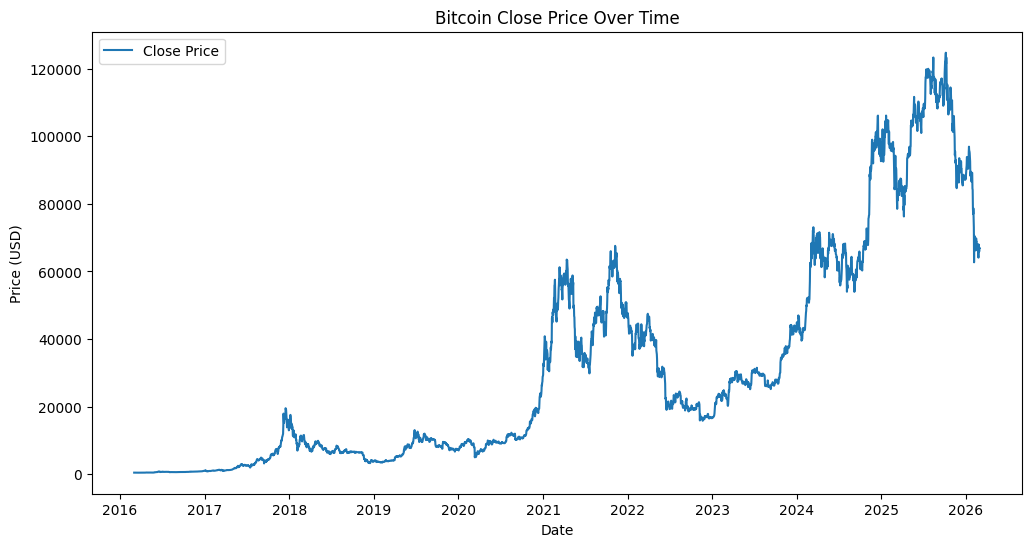

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(btc['Close'], label='Close Price')
plt.title('Bitcoin Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(btc[['Close']])

In [17]:
X, y = [], []
for i in range(60, len(data_scaled)):
    X.append(data_scaled[i - 60:i, 0])
    y.append(data_scaled[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

model_lstm = Sequential([
    Input(shape=(X.shape[1], 1)),
    LSTM(units=50, return_sequences=True),
    LSTM(units=50),
    Dense(1)
])

model_lstm.compile(loss='mean_squared_error', optimizer='adam')
model_lstm.fit(X, y, epochs=10, batch_size=32, verbose=0)


In [18]:
train_predictions_scaled = model_lstm.predict(X, verbose=0)
train_predictions = scaler.inverse_transform(train_predictions_scaled)
y_actual = scaler.inverse_transform(y.reshape(-1, 1))

lstm_rmse = float(np.sqrt(mean_squared_error(y_actual, train_predictions)))
print(f'LSTM RMSE: {lstm_rmse:.4f}')

pred_input = data_scaled[-60:]
pred_input = pred_input.reshape(1, 60, 1)

lstm_predictions = []

for _ in range(30):
    next_pred = model_lstm.predict(pred_input, verbose=0)[0][0]
    lstm_predictions.append(next_pred)
    pred_input = np.append(pred_input[:, 1:, :], [[[next_pred]]], axis=1)

lstm_predictions_actual = scaler.inverse_transform(np.array(lstm_predictions).reshape(-1, 1))


LSTM RMSE: 1879.4804


In [21]:
last_date = btc.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
lstm_forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close_Price': lstm_predictions_actual.flatten()
})
lstm_forecast = lstm_forecast_df.set_index('Date')
lstm_forecast


,Predicted_Close_Price
Date,
2026-03-02,66579.945312
2026-03-03,66651.859375
2026-03-04,66707.796875
2026-03-05,66754.289062
2026-03-06,66795.007812
2026-03-07,66832.179688
2026-03-08,66867.046875
2026-03-09,66900.281250
2026-03-10,66932.203125


In [20]:
next_day_price = float(lstm_forecast['LSTM_Predicted_Close'].iloc[0])
last_close = float(btc['Close'].iloc[-1])

try:
    import streamlit as st
    delta_value = next_day_price - last_close
    delta_pct = (delta_value / last_close) * 100 if last_close else 0.0
    st.metric(
        'Next Day Predicted Price',
        f'${next_day_price:,.2f}',
        f'{delta_value:+,.2f} ({delta_pct:+.2f}%) vs last close'
    )
    st.subheader('LSTM Forecast')
    st.line_chart(lstm_forecast)
except Exception as e:
    print(f'Streamlit display skipped: {e}')
    print(f'Next day predicted price: ${next_day_price:,.2f}')
    print('Run `streamlit run app.py` to see the Streamlit UI.')


2026-03-01 20:12:44.552 
  command:

    streamlit run C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
